# DynamicCARLEnv — Getting Started

This notebook demonstrates **dynamic context scheduling** as a training instrument for contextual
reinforcement learning. Rather than sampling a fixed physics parameter at the start of each episode,
we let it evolve *within* the episode according to a schedule, for example sinusoidal sweeps, random walks,
piecewise jumps, and more.

**What this notebook covers**
1. Quick start: CartPole with a sinusoidal pole-length schedule
2. Comparing schedule families side-by-side
3. BipedalWalker with a dynamic payload offset
4. CarRacing with a dynamic center-of-mass shift
5. Interactive play (opens a game window, control a dynamic environment youselves)

## Setup

Run these once from the repo root:

```bash
# 1. The dynamic-carl package
pip install -e .

# 2. CARL (not on PyPI)
pip install git+https://github.com/automl/CARL.git

# 3. Box2D environments (CartPole, BipedalWalker, CarRacing)
pip install swig box2d-py

# 4. Pretrained PPO models (sections 1–4)
pip install stable-baselines3

# 5. Interactive CarRacing window (section 6b)
pip install pygame

# 6. MuJoCo environments — Go2 / Quadruped (section 8)
#    Use --no-deps to skip the optional labmaze dependency (requires Bazel)
pip install mujoco
pip install dm-control --no-deps
pip install dm-env pyopengl
```

Sections 1–7 work without MuJoCo; section 8 additionally needs step 6 above.

In [ ]:
import sys, os

# MuJoCo rendering backend — glfw works for both offscreen rgb_array and the interactive viewer
os.environ.setdefault("MUJOCO_GL", "glfw")

_nb_dir = os.getcwd()  # .../notebooks/
_src = os.path.abspath(os.path.join(_nb_dir, "../src"))
if _src not in sys.path:
    sys.path.insert(0, _src)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import animation
from IPython.display import HTML, display

from dynamic_carl.env_wrappers import GymDynamicContextCarlWrapper
from dynamic_carl.gym_context_updates import (
    make_sinusoidal, make_cosine_annealing, make_random_walk,
    make_piecewise_constant, make_continuous_incrementer,
    make_sudden_jump, make_levy_walk, make_identity,
)
from utils.gym_utils import (
    cartpole_env_factory, make_cp_ctx_accessor,
    walker_env_factory,
    racer_env_factory, get_racer_payload_x, get_racer_payload_y, set_racer_payload,
    _get_payload_com_x, _set_payload_com_x,
)

_MODELS_DIR = os.path.abspath(os.path.join(_nb_dir, "../models"))
print("Imports OK")
print("  src    :", _src)
print("  models :", _MODELS_DIR)

---
## 1. CartPole — Sinusoidal Pole-Length Schedule

The pole length oscillates between 0.3 m and 0.7 m within each episode while a
random policy runs. The plot on the left shows the context trajectory; the frames
on the right show the environment at the marked timesteps.

In [ ]:
from stable_baselines3 import PPO
from gymnasium import ObservationWrapper
import gymnasium as gym

_CP_MODEL_PATH = os.path.join(_MODELS_DIR, "cartpole_ppo_no_ctx_150k.zip")
cp_model = PPO.load(_CP_MODEL_PATH)
print("CartPole model loaded.")

_cp_get, _cp_set = make_cp_ctx_accessor("length")


class DropContext(ObservationWrapper):
    """Drop 'context' from the observation dict, matching the no_ctx training setup."""
    def __init__(self, env):
        super().__init__(env)
        spaces = {k: v for k, v in env.observation_space.spaces.items() if k != "context"}
        self.observation_space = gym.spaces.Dict(spaces)

    def observation(self, obs):
        return {k: v for k, v in obs.items() if k != "context"}


def make_cartpole(scheduler, render_mode="rgb_array"):
    base_length = 0.5
    env = cartpole_env_factory(
        contexts={0: {"length": base_length}},
        render_mode=render_mode,
        ctx_to_observe=[],
    )
    env = GymDynamicContextCarlWrapper(
        env,
        feature_update_fns={"length": scheduler},
        ctx_getters={"length": _cp_get},
        ctx_setters={"length": _cp_set},
        ctx_to_observe=[],
        observe_context_mode="none",
        mutate_obs_space=True,
    )
    return DropContext(env)


def rollout(env, n_steps=500, seed=0, policy=None):
    """Run one episode (stops at termination). Returns (frames, context_values)."""
    frames, ctx_vals = [], []
    obs, _ = env.reset(seed=seed)
    for _ in range(n_steps):
        if policy is not None:
            action, _ = policy.predict(obs, deterministic=True)
        else:
            action = env.action_space.sample()
        obs, _, terminated, truncated, _ = env.step(action)
        frames.append(env.render())
        ctx_vals.append(env.get_true_context())
        if terminated or truncated:
            break
    env.close()
    return frames, ctx_vals


sin_sched = make_sinusoidal("length", amplitude=0.2, period=100,
                             min_val=0.1, max_val=1.2, seed=0)
cp_env = make_cartpole(sin_sched)
frames, ctx_vals = rollout(cp_env, n_steps=500, policy=cp_model)

lengths = [v["length"] for v in ctx_vals]
print(f"Pole length range: {min(lengths):.3f} – {max(lengths):.3f} m  ({len(frames)} frames)")

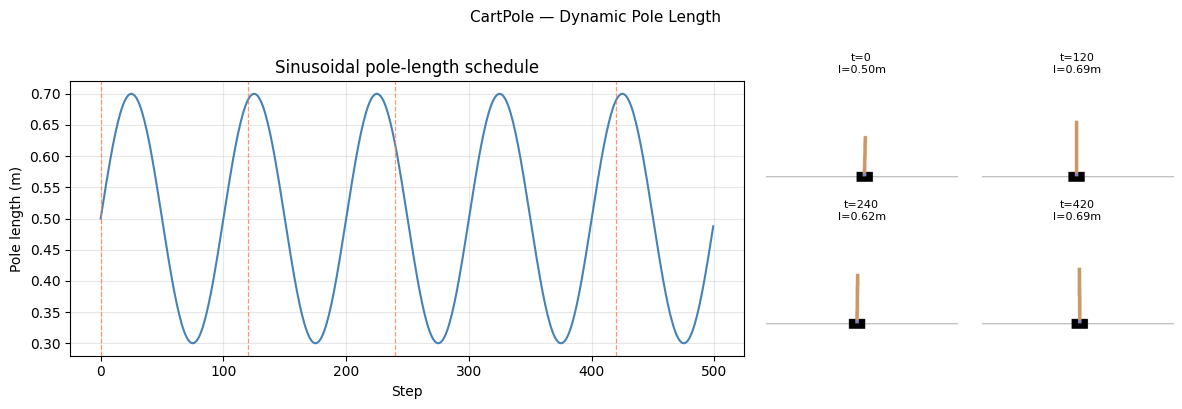

In [37]:
# Plot: context trajectory + 4 key frames
snapshot_steps = [0, 120, 240, 420]  # steps at which to show a frame

fig = plt.figure(figsize=(12, 4))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.6, 1])

# Left: context trajectory
ax_ctx = fig.add_subplot(gs[0])
ax_ctx.plot(lengths, color="steelblue", linewidth=1.5)
for s in snapshot_steps:
    ax_ctx.axvline(s, color="coral", linestyle="--", linewidth=0.9, alpha=0.8)
ax_ctx.set_xlabel("Step")
ax_ctx.set_ylabel("Pole length (m)")
ax_ctx.set_title("Sinusoidal pole-length schedule")
ax_ctx.grid(True, alpha=0.3)

# Right: 4 key frames
gs_right = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[1],
                                             hspace=0.15, wspace=0.05)
for i, step in enumerate(snapshot_steps):
    ax = fig.add_subplot(gs_right[i // 2, i % 2])
    ax.imshow(frames[step])
    ax.set_title(f"t={step}\nl={lengths[step]:.2f}m", fontsize=8)
    ax.axis("off")

plt.suptitle("CartPole — Dynamic Pole Length", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

---
## 2. Comparing Schedule Families

Six canonical schedule families, each inducing qualitatively different temporal
structure on the context within an episode.

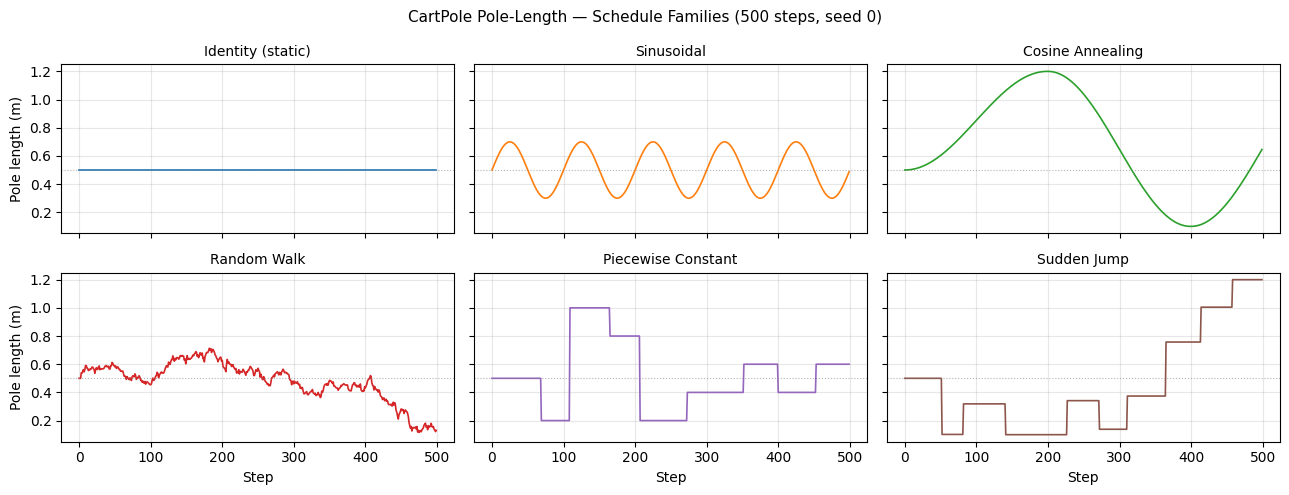

In [19]:
MIN_LEN, MAX_LEN = 0.1, 1.2

schedulers = {
    "Identity (static)": make_identity(
        "length", min_val=MIN_LEN, max_val=MAX_LEN),
    "Sinusoidal": make_sinusoidal(
        "length", amplitude=0.2, period=100, min_val=MIN_LEN, max_val=MAX_LEN, seed=0),
    "Cosine Annealing": make_cosine_annealing(
        "length", T_max=200, mode="cycle", min_val=MIN_LEN, max_val=MAX_LEN, seed=0),
    "Random Walk": make_random_walk(
        "length", std=0.015, min_val=MIN_LEN, max_val=MAX_LEN, seed=0),
    "Piecewise Constant": make_piecewise_constant(
        "length",
        values=[0.2, 0.4, 0.6, 0.8, 1.0],
        interval_range=(40, 80),
        min_val=MIN_LEN, max_val=MAX_LEN, seed=0),
    "Sudden Jump": make_sudden_jump(
        "length", step_size_range=(0.2, 0.4), interval_range=(30, 60),
        min_val=MIN_LEN, max_val=MAX_LEN, seed=0),
}

N_STEPS = 500
sched_trajectories = {}

for name, sched in schedulers.items():
    env = make_cartpole(sched)
    _, ctx = rollout(env, n_steps=N_STEPS, seed=0, policy=cp_model)
    sched_trajectories[name] = [v["length"] for v in ctx]

fig, axes = plt.subplots(2, 3, figsize=(13, 5), sharex=True, sharey=True)
colors = plt.cm.tab10.colors

for ax, (name, traj), color in zip(axes.flat, sched_trajectories.items(), colors):
    ax.plot(traj, color=color, linewidth=1.2)
    ax.axhline(0.5, color="grey", linestyle=":", linewidth=0.8, alpha=0.6)
    ax.set_title(name, fontsize=10)
    ax.set_ylim(MIN_LEN - 0.05, MAX_LEN + 0.05)
    ax.grid(True, alpha=0.3)

for ax in axes[1]:
    ax.set_xlabel("Step")
for ax in axes[:, 0]:
    ax.set_ylabel("Pole length (m)")

plt.suptitle("CartPole Pole-Length — Schedule Families (500 steps, seed 0)", fontsize=11)
plt.tight_layout()
plt.show()

---
## 3. BipedalWalker — Dynamic Payload Offset

A 2 kg payload is attached to the walker's torso. The `COM_X` context shifts it
along the longitudinal axis, changing the center of mass and requiring the walker
to adapt its gait within the episode.

In [ ]:
import gymnasium as gym
from gymnasium.wrappers import FlattenObservation
from carl.context.context_space import UniformFloatContextFeature
from dynamic_carl.env_wrappers import ContextOnlyNormalize
from dynamic_carl.base_classes import PartialContextWrapper

_WALKER_MODEL_PATH = os.path.join(_MODELS_DIR, "walker_ppo_com_x_3M.zip")

_W_PAYLOAD = {"mass": 1.5, "radius": 0.4, "y": 0.0}  # must match training config

walker_sin = make_sinusoidal(
    "COM_X", amplitude=0.4, period=200,
    min_val=-0.6, max_val=0.6, seed=42)

_base_walker = walker_env_factory(
    contexts={0: {"COM_X": 0.0}},
    render_mode="rgb_array",
    ctx_to_observe=["COM_X"],
    payloaded=True,
    keep_center=False,
    payload_kwargs=_W_PAYLOAD,
)

_walker_dyn = GymDynamicContextCarlWrapper(
    _base_walker,
    feature_update_fns={"COM_X": walker_sin},
    ctx_getters={"COM_X": _get_payload_com_x},
    ctx_setters={"COM_X": lambda e, v: _set_payload_com_x(
        e, x=float(v), mass=_W_PAYLOAD["mass"],
        radius=_W_PAYLOAD["radius"], y_fixed=_W_PAYLOAD["y"])},
    ctx_to_observe=["COM_X"],
    observe_context_mode="live",
    mutate_obs_space=False,
    worker_id=0,
    verbose=False,
    dctx_features_definitions={
        "COM_X": UniformFloatContextFeature("COM_X", lower=-0.6, upper=0.6, default_value=0.0)
    },
)

_walker_norm = ContextOnlyNormalize(_walker_dyn, {"COM_X": (-0.60, 0.60)})

if isinstance(_walker_norm.observation_space, gym.spaces.Dict):
    _ctx_sp = _walker_norm.observation_space.spaces.get("context")
    if isinstance(_ctx_sp, gym.spaces.Dict) and len(_ctx_sp.spaces) == 0:
        _walker_norm = PartialContextWrapper(_walker_norm, selected_context_keys=[])

walker_env = FlattenObservation(_walker_norm)
walker_model = PPO.load(_WALKER_MODEL_PATH)
print(f"Walker model loaded. Obs dim: {walker_env.observation_space.shape}")

walker_frames, walker_ctx = rollout(walker_env, n_steps=600, seed=1, policy=walker_model)
com_x_vals = [v["COM_X"] for v in walker_ctx]
print(f"Episode length: {len(walker_frames)} steps")
print(f"COM_X range: {min(com_x_vals):.3f} – {max(com_x_vals):.3f} m")

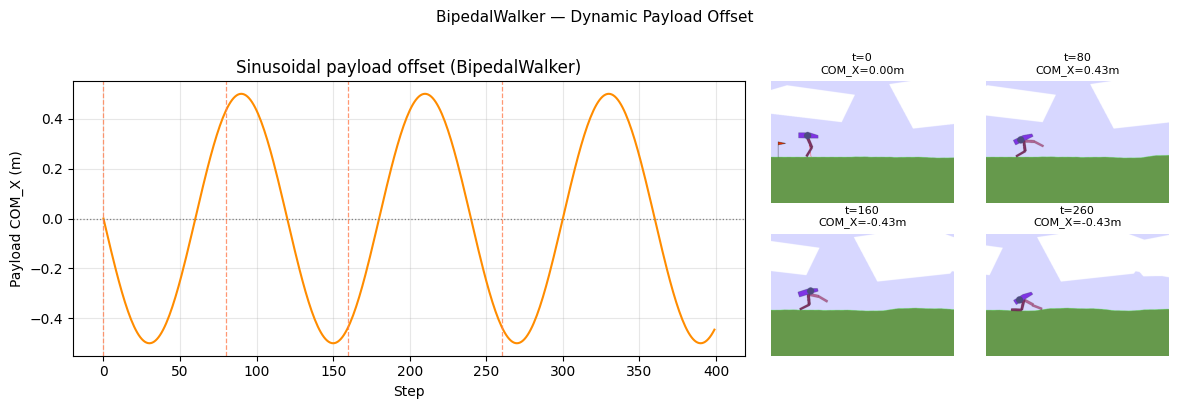

In [36]:
snap_steps = [0, 80, 160, 260]

fig = plt.figure(figsize=(12, 4))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.6, 1])

ax_ctx = fig.add_subplot(gs[0])
ax_ctx.plot(com_x_vals, color="darkorange", linewidth=1.5)
ax_ctx.axhline(0, color="grey", linestyle=":", linewidth=0.9)
for s in snap_steps:
    ax_ctx.axvline(s, color="coral", linestyle="--", linewidth=0.9, alpha=0.8)
ax_ctx.set_xlabel("Step")
ax_ctx.set_ylabel("Payload COM_X (m)")
ax_ctx.set_title("Sinusoidal payload offset (BipedalWalker)")
ax_ctx.grid(True, alpha=0.3)

gs_right = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[1],
                                             hspace=0.25, wspace=0.05)
for i, step in enumerate(snap_steps):
    ax = fig.add_subplot(gs_right[i // 2, i % 2])
    ax.imshow(walker_frames[step])
    ax.set_title(f"t={step}\nCOM_X={com_x_vals[step]:.2f}m", fontsize=8)
    ax.axis("off")

plt.suptitle("BipedalWalker — Dynamic Payload Offset", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

---
## 4. CarRacing — Dynamic Center-of-Mass Shift

A 1 kg payload is attached to the car hull. `COM_Y` shifts it laterally, making
the car under- or oversteer as the weight moves side to side during a lap.

In [22]:
RACER_MASS = 1.0
RACER_RADIUS = 0.5

racer_sin = make_sinusoidal(
    "COM_X", amplitude=0.5, period=120,
    min_val=-0.8, max_val=0.8, seed=7)

base_racer = racer_env_factory(
    contexts={0: {"VEHICLE_ID": 0, "COM_X": 0.0, "COM_Y": 0.0}},
    render_mode="rgb_array",
    ctx_to_observe=[],
    payloaded=True,
    payload_kwargs={"mass": RACER_MASS, "radius": RACER_RADIUS},
)

racer_env = GymDynamicContextCarlWrapper(
    base_racer,
    feature_update_fns={"COM_X": racer_sin},
    ctx_getters={
        "COM_X": get_racer_payload_x,
        "COM_Y": get_racer_payload_y,
    },
    ctx_setters={
        "COM_X": lambda e, v: set_racer_payload(
            e, x_value=float(v), y_value=None, mass=RACER_MASS, radius=RACER_RADIUS),
        "COM_Y": lambda e, v: set_racer_payload(
            e, x_value=None, y_value=float(v), mass=RACER_MASS, radius=RACER_RADIUS),
    },
    ctx_to_observe=[],
    observe_context_mode="none",
    mutate_obs_space=True,
)


class ForwardPolicy:
    """Drives straight at high throttle — keeps the car moving for context viz."""
    _action = np.array([0.0, 0.8, 0.0])  # steer, gas, brake

    def predict(self, obs, deterministic=True):
        return self._action, None


racer_frames, racer_ctx = rollout(racer_env, n_steps=400, seed=3, policy=ForwardPolicy())
com_x_vals = [v["COM_X"] for v in racer_ctx]
print(f"Episode length: {len(racer_frames)} steps")
print(f"COM_X range: {min(com_x_vals):.3f} – {max(com_x_vals):.3f} m")

Episode length: 400 steps
COM_X range: -0.500 – 0.500 m


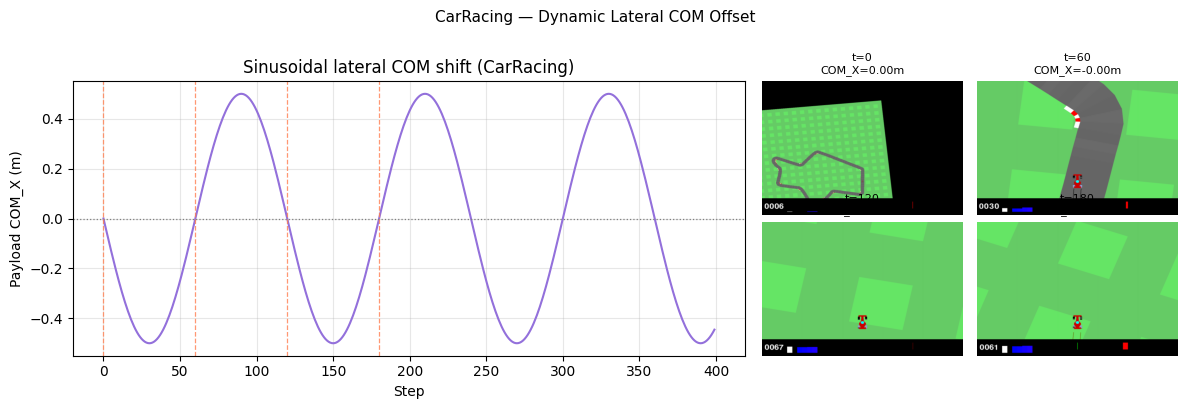

In [39]:
snap_steps = [0, 60, 120, 180]

fig = plt.figure(figsize=(12, 4))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.6, 1])

ax_ctx = fig.add_subplot(gs[0])
ax_ctx.plot(com_x_vals, color="mediumpurple", linewidth=1.5)
ax_ctx.axhline(0, color="grey", linestyle=":", linewidth=0.9)
for s in snap_steps:
    ax_ctx.axvline(s, color="coral", linestyle="--", linewidth=0.9, alpha=0.8)
ax_ctx.set_xlabel("Step")
ax_ctx.set_ylabel("Payload COM_X (m)")
ax_ctx.set_title("Sinusoidal lateral COM shift (CarRacing)")
ax_ctx.grid(True, alpha=0.3)

gs_right = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[1],
                                             hspace=0.05, wspace=0.05)
for i, step in enumerate(snap_steps):
    ax = fig.add_subplot(gs_right[i // 2, i % 2])
    ax.imshow(racer_frames[step])
    ax.set_title(f"t={step}\nCOM_X={com_x_vals[step]:.2f}m", fontsize=8)
    ax.axis("off")

plt.suptitle("CarRacing — Dynamic Lateral COM Offset", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Animated Rollout

Watch the context evolve frame-by-frame alongside the rendered environment.

In [24]:
def animate_rollout(frames, ctx_values, ctx_key, title, color="steelblue",
                    fps=30, max_frames=300):
    """Create an inline animation: environment frame + live context trajectory."""
    frames = frames[:max_frames]
    vals = ctx_values[:max_frames]

    fig, (ax_env, ax_ctx) = plt.subplots(1, 2, figsize=(10, 4))

    im = ax_env.imshow(frames[0])
    ax_env.axis("off")

    line, = ax_ctx.plot([], [], color=color, linewidth=1.5)
    marker, = ax_ctx.plot([], [], "o", color="coral", markersize=6, zorder=5)
    ax_ctx.set_xlim(0, len(vals))
    ax_ctx.set_ylim(min(vals) - 0.05, max(vals) + 0.05)
    ax_ctx.set_xlabel("Step")
    ax_ctx.set_ylabel(ctx_key)
    ax_ctx.grid(True, alpha=0.3)

    def update(i):
        im.set_data(frames[i])
        line.set_data(range(i + 1), vals[:i + 1])
        marker.set_data([i], [vals[i]])
        ax_env.set_title(f"{title}  step {i}", fontsize=10)
        return im, line, marker

    ani = animation.FuncAnimation(
        fig, update, frames=len(frames), interval=1000 / fps, blit=True)
    plt.tight_layout()
    plt.close(fig)
    return ani


# Animate CartPole (sinusoidal pole length)
ani = animate_rollout(frames, lengths, ctx_key="Pole length (m)",
                      title="CartPole / Sinusoidal", fps=20, max_frames=200)
HTML(ani.to_jshtml())

---
## 6. Interactive Play (local Jupyter only)

Run the cells below to **open a game window** and control the environment yourself.
This requires a local display (not Colab).  
**Interrupt the kernel** (`Kernel → Interrupt`) to stop.

### 6a. CartPole — watch the pole length change under you

No controls needed: the random policy runs automatically so you can see the
sinusoidal schedule in action in the game window.

In [25]:
import time

sin_sched2 = make_sinusoidal("length", amplitude=0.3, period=80,
                              min_val=0.1, max_val=1.2, seed=0)
play_cp = make_cartpole(sin_sched2, render_mode="human")
obs, _ = play_cp.reset(seed=0)

try:
    for step in range(2000):
        action, _ = cp_model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = play_cp.step(action)
        play_cp.render()
        time.sleep(1 / 60)
        if terminated or truncated:
            break
finally:
    play_cp.close()
print(f"Episode ended at step {step + 1}.")

Episode ended at step 500.


### 6b. CarRacing — keyboard control with dynamic payload

Controls:
- **↑** gas &nbsp;&nbsp; **↓** brake &nbsp;&nbsp; **←/→** steer
- Click the game window once to make sure it captures keyboard focus.

The payload (cyan marker) drifts laterally — notice how the car's handling
changes as weight shifts left and right.

In [26]:
import pygame
import time

RACER_MASS_PLAY = 1.0
RACER_RADIUS_PLAY = 0.5

play_sin = make_sinusoidal(
    "COM_X", amplitude=0.6, period=150,
    min_val=-0.8, max_val=0.8, seed=0)

play_base = racer_env_factory(
    contexts={0: {"VEHICLE_ID": 0, "COM_X": 0.0, "COM_Y": 0.0}},
    render_mode="human",
    ctx_to_observe=[],
    payloaded=True,
    payload_kwargs={"mass": RACER_MASS_PLAY, "radius": RACER_RADIUS_PLAY},
)

play_racer = GymDynamicContextCarlWrapper(
    play_base,
    feature_update_fns={"COM_X": play_sin},
    ctx_getters={
        "COM_X": get_racer_payload_x,
        "COM_Y": get_racer_payload_y,
    },
    ctx_setters={
        "COM_X": lambda e, v: set_racer_payload(
            e, x_value=float(v), y_value=None,
            mass=RACER_MASS_PLAY, radius=RACER_RADIUS_PLAY),
        "COM_Y": lambda e, v: set_racer_payload(
            e, x_value=None, y_value=float(v),
            mass=RACER_MASS_PLAY, radius=RACER_RADIUS_PLAY),
    },
    ctx_to_observe=[],
    observe_context_mode="none",
    mutate_obs_space=True,
)

obs, _ = play_racer.reset(seed=0)
print("Window opened — click it to focus, then use arrow keys.")
print("Episode ends automatically on crash or lap completion.")

try:
    while True:
        pygame.event.pump()
        keys = pygame.key.get_pressed()

        steer = (-1.0 if keys[pygame.K_LEFT] else 0.0) + \
                (+1.0 if keys[pygame.K_RIGHT] else 0.0)
        gas   = 1.0 if keys[pygame.K_UP] else 0.0
        brake = 0.8 if keys[pygame.K_DOWN] else 0.0

        obs, reward, terminated, truncated, info = play_racer.step([steer, gas, brake])
        play_racer.render()
        time.sleep(1 / 60)

        ctx_now = play_racer.get_true_context()
        print(f"\rCOM_X = {ctx_now['COM_X']:+.3f} m   reward = {reward:+.1f}   ",
              end="", flush=True)

        if terminated or truncated:
            print("\nEpisode done.")
            break
finally:
    play_racer.close()

/home/martin/Code/dynamic_contextual_rl/.venv/lib/python3.13/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_context_features to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_context_features` for environment variables or `env.get_wrapper_attr('get_context_features')` that will search the reminding wrappers.
  logger.warn(


Window opened — click it to focus, then use arrow keys.
Episode ends automatically on crash or lap completion.
COM_X = +0.050 m   reward = -0.1   

/home/martin/Code/dynamic_contextual_rl/.venv/lib/python3.13/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.car to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.car` for environment variables or `env.get_wrapper_attr('car')` that will search the reminding wrappers.
  logger.warn(


COM_X = -0.507 m   reward = -0.1   
Episode done.


---
## 7. Custom Schedulers

Any object with `reset(env, episode_id, ctx, worker_id)` and `__call__(env, step, ctx, verbose)`
can be used as a scheduler. Here's a minimal example that applies a triangle wave.

/home/martin/Code/dynamic_contextual_rl/.venv/lib/python3.13/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_true_context to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_true_context` for environment variables or `env.get_wrapper_attr('get_true_context')` that will search the reminding wrappers.
  logger.warn(


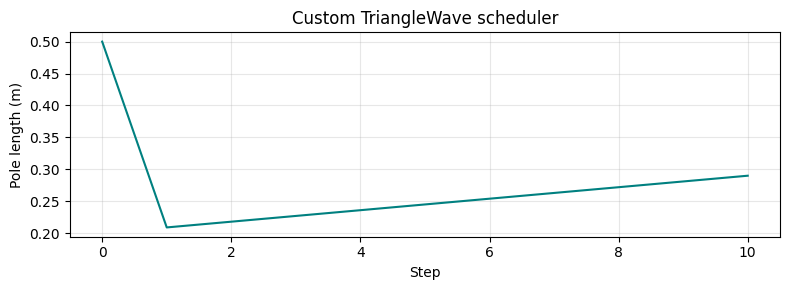

In [27]:
import numpy as np

class TriangleWave:
    """Linearly sweeps between min_val and max_val with period `period`."""

    def __init__(self, attribute, period=200, min_val=0.1, max_val=1.0):
        self.attribute = attribute
        self.period = period
        self.min_val = min_val
        self.max_val = max_val

    def reset(self, env, episode_id, ctx=None, worker_id=0):
        self._step = 0

    def __call__(self, env, step, ctx, verbose=False):
        self._step += 1
        t = self._step % self.period
        half = self.period / 2
        frac = t / half if t < half else (self.period - t) / half
        val = self.min_val + frac * (self.max_val - self.min_val)
        val = float(np.clip(val, self.min_val, self.max_val))
        # apply to environment
        setter = lambda e, v: setattr(e.unwrapped, self.attribute, float(v))
        from utils.gym_utils import get_gym_base_env
        get_gym_base_env(env).__setattr__(self.attribute, val)
        return val


tri = TriangleWave("length", period=200, min_val=0.2, max_val=1.1)
tri_cp = make_cartpole(tri)
_, tri_ctx = rollout(tri_cp, n_steps=500, seed=0)
tri_lengths = [v["length"] for v in tri_ctx]

plt.figure(figsize=(8, 3))
plt.plot(tri_lengths, color="teal")
plt.xlabel("Step")
plt.ylabel("Pole length (m)")
plt.title("Custom TriangleWave scheduler")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. MuJoCo Environments — Dynamic Gravity / Wind (Go2 & Quadruped)

These environments use **MuJoCo + dm_control** and the `dc_updaters` API (a simpler step-lambda
interface used before `GymDynamicContextCarlWrapper`). Any physical parameter MuJoCo exposes —
gravity, wind, friction, payload mass — can be scheduled the same way.

**Requirements:** `mujoco`, `dm_control`, and a valid MuJoCo license (free since 2022).

The demo below starts Go2 in near-zero gravity (robot bounces freely), then ramps gravity up to
Earth standard over the episode — the robot visibly gets heavier and collapses.

In [ ]:
from dmc_envs.dc_envs.go2_as_dmc import CARLDmcGo2Env as Go2Env

# Near-weightless for 300 steps, then full Earth gravity kicks in — robot collapses visibly.
def _gravity_step(step):
    return -9.8 if step >= 300 else -0.1

go2_env = Go2Env(
    render_mode="rgb_array",
    contexts={0: {"gravity_z": -0.1, "payload_mass": 1.0}},
    dc_updaters={"gravity_z": _gravity_step},
)

frames_go2, gravity_vals = [], []
obs = go2_env.reset()
for step in range(600):
    action = go2_env.action_space.sample()  # random policy — robot flails under low gravity
    obs, reward, terminated, truncated, info = go2_env.step(action)
    frames_go2.append(go2_env.render())
    gravity_vals.append(go2_env.env.env.physics.model.opt.gravity[2])
    if terminated or truncated:
        break
go2_env.close()
print(f"{len(frames_go2)} frames, gravity range: {min(gravity_vals):.2f} – {max(gravity_vals):.2f} m/s²")

snap_steps = [s for s in [0, 150, 299, 599] if s < len(frames_go2)]

fig = plt.figure(figsize=(12, 4))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.6, 1])

ax_ctx = fig.add_subplot(gs[0])
ax_ctx.plot(gravity_vals, color="crimson", linewidth=1.5)
ax_ctx.axvline(300, color="black", linestyle="--", linewidth=1.2, alpha=0.7, label="gravity switch")
for s in snap_steps:
    ax_ctx.axvline(s, color="coral", linestyle="--", linewidth=0.9, alpha=0.6)
ax_ctx.set_xlabel("Step")
ax_ctx.set_ylabel("Gravity Z (m/s²)")
ax_ctx.set_title("Step-function gravity — Go2 (random policy)")
ax_ctx.legend(fontsize=8)
ax_ctx.grid(True, alpha=0.3)

gs_right = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[1], hspace=0.2, wspace=0.05)
for i, step in enumerate(snap_steps):
    ax = fig.add_subplot(gs_right[i // 2, i % 2])
    ax.imshow(frames_go2[step])
    ax.set_title(f"t={step}  g={gravity_vals[step]:.1f}", fontsize=8)
    ax.axis("off")

plt.suptitle("Go2 — Sudden Gravity Switch at t=300", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

### 8b. Go2 — Interactive Viewer (local only)

Opens the dm_control viewer window. Use the mouse to rotate/zoom the camera.
The viewer runs its own loop — **close the window** to return to the notebook.

In [29]:
go2_interactive = Go2Env(
    render_mode="human",
    contexts={0: {"gravity_z": -0.1, "payload_mass": 1.0}},
    dc_updaters={"gravity_z": _gravity_step},
)
go2_interactive.reset()
go2_interactive.render()   # blocks until window is closed — gravity switches at step 300
go2_interactive.close()